In [1]:
from comet_ml import Experiment
import sys
sys.path.append('../')
import numpy as np
import os
import torch
import time
from pathlib import Path
import math
import matplotlib.pyplot as plt
import torch
from pydose_rt.data import Patient, OptimizationConfig, MachineConfig, loaders, BeamSequence
from pydose_rt import DoseEngine
from pydose_rt.layers import BeamValidationLayer
from pydose_rt.utils.plotting import *
from pydose_rt.physics.kernels.pencil_beam_model import *
from pydose_rt.utils.grad_monitor import GradMonitor
from IPython.display import clear_output
import numpy as np
from pydose_rt.objectives.losses import dvh_percentile_loss, dvh_volume_at_dose_loss
from pydose_rt.objectives.metrics import result_validation
from pydose_rt.utils.utils import get_initial_weights
from pydose_rt.utils.plotting import print_results, make_animation
from pydose_rt.utils.plotting import overlay_mask_outline

In [2]:
raw_data = np.load("../example_data/water_patient.npz")["structures"]
["CTV", "PTV", "FemoralHead_L", "FemoralHead_R", "Bladder", "Rectum", "External"]
ct_image = torch.from_numpy(np.where(raw_data != 0.0, 0.0, -1000.0))
external = torch.from_numpy(raw_data > 0.0)
rectum = torch.from_numpy(raw_data == 2.0)
bladder = torch.from_numpy(raw_data == 3.0)
femoralhead_r = torch.from_numpy(raw_data == 4.0)
femoralhead_l = torch.from_numpy(raw_data == 5.0)
ptv = torch.from_numpy(raw_data == 6.0)
ctv = torch.from_numpy(raw_data == 7.0)

patient = Patient(ct_tensor = ct_image, resolution=(2.0, 2.0, 2.0))
patient.add_mask("External", external)
patient.add_mask("Rectum", rectum)
patient.add_mask("Bladder", bladder)
patient.add_mask("FemoralHead_L", femoralhead_l)
patient.add_mask("FemoralHead_R", femoralhead_r)
patient.add_mask("PTV", ptv)
patient.add_mask("CTV", ctv)

colors = {"External": "orange",
          "Rectum": "purple",
          "Bladder": "yellow",
          "FemoralHead_L": "green",
          "FemoralHead_R": "blue",
          "PTV": "black",
          "CTV": "red"}

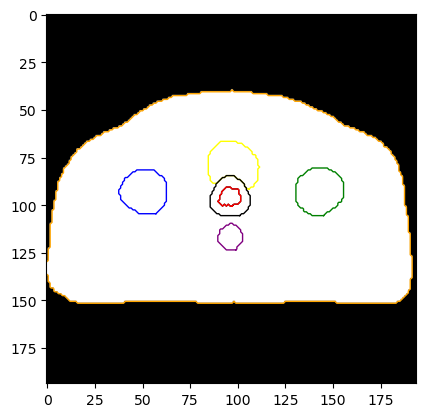

In [3]:
slice_idx = 63
plt.imshow(patient.density_image.cpu().detach().numpy()[slice_idx, :, :], cmap='gray')
for struct_name in patient.structures.keys():
    overlay_mask_outline(patient.structures[struct_name].cpu().detach().numpy()[slice_idx, :, :], color=colors[struct_name])

In [4]:

device =  torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

machine_config = MachineConfig(preset="../src/pydose_rt/data/machine_presets/umea_10MV.json")
number_of_beams = 30
gantry_angles = torch.from_numpy(np.linspace(-170, 170, number_of_beams, endpoint=False))
number_of_leaf_pairs = 60
field_size = (400, 400)
iso_center = (0.0, 0.0, 0.0)
collimator_angles = torch.from_numpy(np.array([0.0 for _ in range(number_of_beams)]))
sid = 1000.0
open_field_size = 100.0
kernel_size = 15

beam_sequence = BeamSequence.create(gantry_angles,
                                    number_of_leaf_pairs,
                                    field_size,
                                    iso_center,
                                    collimator_angles,
                                    sid,
                                    open_field_size,
                                    device,
                                    dtype,
                                    True)
patient = patient.to(device).to(dtype)

engine = DoseEngine(
    machine_config=machine_config,
    image_template=patient.density_image,
    beam_template=beam_sequence, 
    downsampling_factor=(1, 1, 1),
    kernel_size=kernel_size, 
    adjust_values=True,
    dtype=dtype, 
    device=device
)

ct_volume = patient.get_masked_ct("External").unsqueeze(0)


In [5]:
slice_idx = 63
dose_max = 6.5
def plot_progress(epoch, raw_losses, dose_pred):
    plt.figure(figsize=(20, 6))  # Make figure span screen
    plt.suptitle(f'Epoch {epoch}: {[str(np.round(loss.item(), 3)) for loss in raw_losses]}', fontsize=16)
    
    plt.subplot(1,2,1)
    plt.axis('off')
    plt.imshow(patient.density_image.cpu().detach().numpy()[slice_idx, :, :], cmap='gray')
    plt.imshow(dose_pred.cpu().detach().numpy()[slice_idx, :, :], alpha=0.8)
    for struct_name in patient.structures.keys():
        overlay_mask_outline(patient.structures[struct_name].cpu().detach().numpy()[slice_idx, :, :], color=colors[struct_name])
    
    plt.subplot(1,2,2)
    for struct_name in patient.structures.keys():
        roi = patient.structures[struct_name]
        dose_values = dose_pred[roi > 0.0].cpu().detach().numpy()
        if dose_values.size == 0:
            continue
        bins = np.linspace(0, dose_max, 1000)
        hist, bin_edges = np.histogram(dose_values, bins=bins, density=False)
        cumulative_hist = np.cumsum(hist[::-1])[::-1]
        cumulative_hist_normalized = np.divide(cumulative_hist, cumulative_hist.max())
        plt.plot(bin_edges[:-1], cumulative_hist_normalized, linestyle="solid", label=struct_name, color=colors[struct_name])
    
    plt.show()

In [6]:
patience = 0
epoch = 0
lr = 1.0
lr_decay = 1e-4
optimizer = torch.optim.AdamW(beam_sequence.parameters(), lr=lr, weight_decay=lr_decay)

def closure():
    optimizer.zero_grad(set_to_none=True)
    
    # Forward
    dose_pred = engine.compute_dose(
        beam_sequence,
        ct_image=ct_volume
    )
    dose_pred = torch.where(patient.structures["External"], dose_pred[0], 0.0)
    raw_losses = []
    raw_losses.append(dvh_percentile_loss(dose_pred, patient.structures["PTV"], 6.1, 95.0, "at_least"))
    raw_losses.append(dvh_percentile_loss(dose_pred, patient.structures["PTV"], 6.3, 100.0, "at_most"))
    raw_losses.append(dvh_percentile_loss(dose_pred, patient.structures["Rectum"], 1.0, 60.0, "at_most"))
    raw_losses.append(dvh_percentile_loss(dose_pred, patient.structures["Rectum"], 3.0, 20.0, "at_most"))
    loss = torch.stack(raw_losses).sum()
    
    # Backprop
    loss.backward()

    return loss, raw_losses, dose_pred


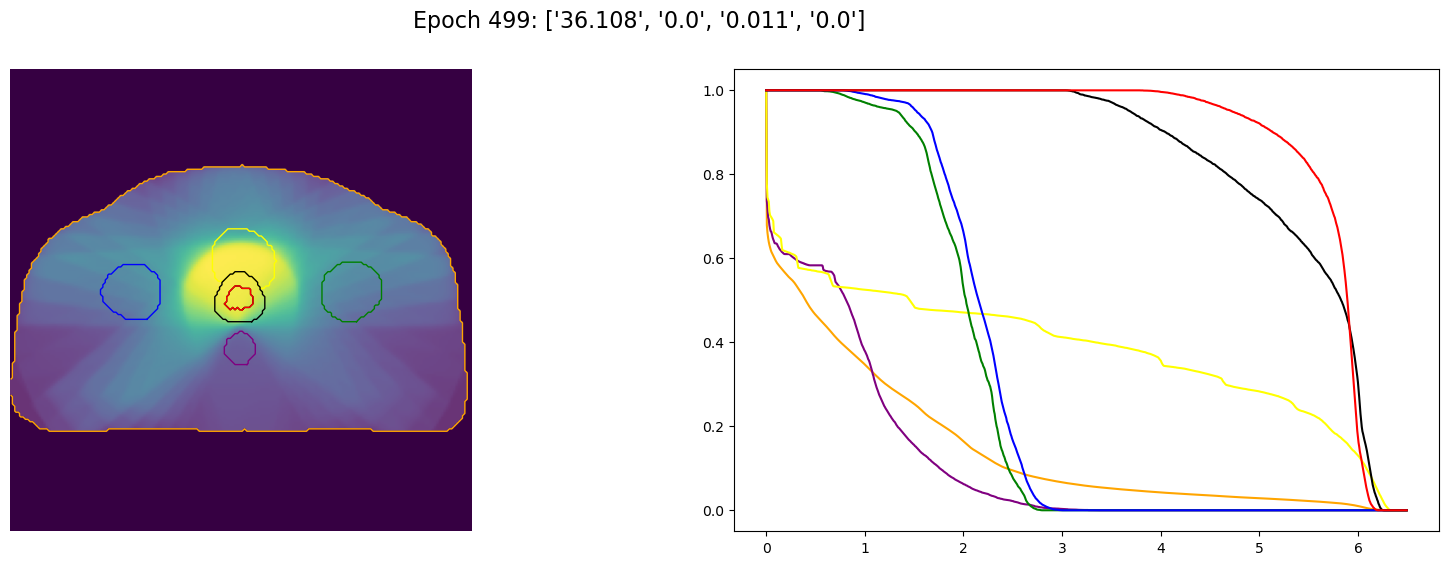

In [7]:

for i in range(500):
    loss, raw_losses, dose_pred = optimizer.step(closure)

    plot_progress(i, raw_losses, dose_pred)
    clear_output(wait=True)